In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [43]:
data = pd.read_csv('Data/Power_Demand_2021-2024.csv')

In [44]:
data.head()

,Unnamed: 0,datetime,Power demand,temp,dwpt,rhum,wdir,wspd,pres,year,month,day,hour,minute,moving_avg_3
0,0,2021-01-01 00:30:00,2014.00,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,30,NaN
1,1,2021-01-01 00:35:00,2005.63,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,35,NaN
2,2,2021-01-01 00:40:00,1977.60,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,40,1999.076667
3,3,2021-01-01 00:45:00,1976.44,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,45,1986.556667
4,4,2021-01-01 00:50:00,1954.37,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,50,1969.470000


In [45]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 393440 entries, 0 to 393439
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Unnamed: 0    393440 non-null  int64  
 1   datetime      393440 non-null  str    
 2   Power demand  393440 non-null  float64
 3   temp          393440 non-null  float64
 4   dwpt          393440 non-null  float64
 5   rhum          393440 non-null  float64
 6   wdir          392900 non-null  float64
 7   wspd          393440 non-null  float64
 8   pres          393440 non-null  float64
 9   year          393440 non-null  int64  
 10  month         393440 non-null  int64  
 11  day           393440 non-null  int64  
 12  hour          393440 non-null  int64  
 13  minute        393440 non-null  int64  
 14  moving_avg_3  393438 non-null  float64
dtypes: float64(8), int64(6), str(1)
memory usage: 45.0 MB


In [46]:
data['datetime'] = pd.to_datetime(data['datetime'])

In [47]:
print(data['datetime'].dtype)

datetime64[us]


In [48]:
data['Time'] = data['datetime'].dt.time

In [49]:
data['datetime'] = data['datetime'].dt.date

In [50]:
data.rename(columns = {'datetime':'Date','Power demand':'Power_Demand','temp':'Temperature'}, inplace = True)

In [51]:
data.columns = data.columns.str.capitalize()

In [52]:
data

,Unnamed: 0,Date,Power_demand,Temperature,Dwpt,Rhum,Wdir,Wspd,Pres,Year,Month,Day,Hour,Minute,Moving_avg_3,Time
0,0,2021-01-01,2014.00,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,30,NaN,00:30:00
1,1,2021-01-01,2005.63,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,35,NaN,00:35:00
2,2,2021-01-01,1977.60,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,40,1999.076667,00:40:00
3,3,2021-01-01,1976.44,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,45,1986.556667,00:45:00
4,4,2021-01-01,1954.37,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,50,1969.470000,00:50:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393435,393435,2024-12-12,2146.84,12.3,6.8,69.0,269.0,1.8,1019.4,2024,12,12,0,10,2174.893333,00:10:00
393436,393436,2024-12-12,2116.66,12.3,6.8,69.0,269.0,1.8,1019.4,2024,12,12,0,15,2139.416667,00:15:00
393437,393437,2024-12-12,2082.77,12.3,6.8,69.0,269.0,1.8,1019.4,2024,12,12,0,20,2115.423333,00:20:00
393438,393438,2024-12-12,2059.17,12.3,6.8,69.0,269.0,1.8,1019.4,2024,12,12,0,25,2086.200000,00:25:00


In [53]:
data.drop(columns = {'Unnamed: 0','Dwpt','Rhum','Wdir','Wspd','Pres','Moving_avg_3'}, inplace = True)

In [54]:
data

,Date,Power_demand,Temperature,Year,Month,Day,Hour,Minute,Time
0,2021-01-01,2014.00,8.0,2021,1,1,0,30,00:30:00
1,2021-01-01,2005.63,8.0,2021,1,1,0,35,00:35:00
2,2021-01-01,1977.60,8.0,2021,1,1,0,40,00:40:00
3,2021-01-01,1976.44,8.0,2021,1,1,0,45,00:45:00
4,2021-01-01,1954.37,8.0,2021,1,1,0,50,00:50:00
...,...,...,...,...,...,...,...,...,...
393435,2024-12-12,2146.84,12.3,2024,12,12,0,10,00:10:00
393436,2024-12-12,2116.66,12.3,2024,12,12,0,15,00:15:00
393437,2024-12-12,2082.77,12.3,2024,12,12,0,20,00:20:00
393438,2024-12-12,2059.17,12.3,2024,12,12,0,25,00:25:00


In [55]:
data = data.set_index('Date')

In [56]:
time_col = data.pop('Time')
data.insert(0,'Time',time_col)

In [57]:
data

,Time,Power_demand,Temperature,Year,Month,Day,Hour,Minute
Date,,,,,,,,
2021-01-01,00:30:00,2014.00,8.0,2021,1,1,0,30
2021-01-01,00:35:00,2005.63,8.0,2021,1,1,0,35
2021-01-01,00:40:00,1977.60,8.0,2021,1,1,0,40
2021-01-01,00:45:00,1976.44,8.0,2021,1,1,0,45
2021-01-01,00:50:00,1954.37,8.0,2021,1,1,0,50
...,...,...,...,...,...,...,...,...
2024-12-12,00:10:00,2146.84,12.3,2024,12,12,0,10
2024-12-12,00:15:00,2116.66,12.3,2024,12,12,0,15
2024-12-12,00:20:00,2082.77,12.3,2024,12,12,0,20


In [58]:
data.isna().sum()

Time            0
Power_demand    0
Temperature     0
Year            0
Month           0
Day             0
Hour            0
Minute          0
dtype: int64

In [59]:
data[['Power_demand','Temperature']].describe()

,Power_demand,Temperature
count,393440.000000,393440.000000
mean,3960.736469,25.527913
std,1300.473773,7.981563
min,1302.080000,4.000000
25%,3074.900000,20.000000
50%,3832.320000,27.000000
75%,4870.465000,31.000000
max,8631.530000,46.400000


In [60]:
data.index = pd.to_datetime(data.index)

In [61]:
data["Week"] = np.minimum((data.index.day - 1) // 7 + 1, 4).astype(int)

In [62]:
data

,Time,Power_demand,Temperature,Year,Month,Day,Hour,Minute,Week
Date,,,,,,,,,
2021-01-01,00:30:00,2014.00,8.0,2021,1,1,0,30,1
2021-01-01,00:35:00,2005.63,8.0,2021,1,1,0,35,1
2021-01-01,00:40:00,1977.60,8.0,2021,1,1,0,40,1
2021-01-01,00:45:00,1976.44,8.0,2021,1,1,0,45,1
2021-01-01,00:50:00,1954.37,8.0,2021,1,1,0,50,1
...,...,...,...,...,...,...,...,...,...
2024-12-12,00:10:00,2146.84,12.3,2024,12,12,0,10,2
2024-12-12,00:15:00,2116.66,12.3,2024,12,12,0,15,2
2024-12-12,00:20:00,2082.77,12.3,2024,12,12,0,20,2


In [63]:
data['Datetime'] = pd.to_datetime(data.index.astype(str) + ' ' + data['Time'].astype(str))

In [64]:
data = data.set_index(data['Datetime'])
data

,Time,Power_demand,Temperature,Year,Month,Day,Hour,Minute,Week,Datetime
Datetime,,,,,,,,,,
2021-01-01 00:30:00,00:30:00,2014.00,8.0,2021,1,1,0,30,1,2021-01-01 00:30:00
2021-01-01 00:35:00,00:35:00,2005.63,8.0,2021,1,1,0,35,1,2021-01-01 00:35:00
2021-01-01 00:40:00,00:40:00,1977.60,8.0,2021,1,1,0,40,1,2021-01-01 00:40:00
2021-01-01 00:45:00,00:45:00,1976.44,8.0,2021,1,1,0,45,1,2021-01-01 00:45:00
2021-01-01 00:50:00,00:50:00,1954.37,8.0,2021,1,1,0,50,1,2021-01-01 00:50:00
...,...,...,...,...,...,...,...,...,...,...
2024-12-12 00:10:00,00:10:00,2146.84,12.3,2024,12,12,0,10,2,2024-12-12 00:10:00
2024-12-12 00:15:00,00:15:00,2116.66,12.3,2024,12,12,0,15,2,2024-12-12 00:15:00
2024-12-12 00:20:00,00:20:00,2082.77,12.3,2024,12,12,0,20,2,2024-12-12 00:20:00


In [65]:
data["Day_Name"] = data.index.day_name()      
data["Day_of_week"] = data.index.dayofweek + 1      
data["Is_Weekend"] = (data.index.dayofweek >= 5).astype(int)  

In [66]:
data

,Time,Power_demand,Temperature,Year,Month,Day,Hour,Minute,Week,Datetime,Day_Name,Day_of_week,Is_Weekend
Datetime,,,,,,,,,,,,,
2021-01-01 00:30:00,00:30:00,2014.00,8.0,2021,1,1,0,30,1,2021-01-01 00:30:00,Friday,5,0
2021-01-01 00:35:00,00:35:00,2005.63,8.0,2021,1,1,0,35,1,2021-01-01 00:35:00,Friday,5,0
2021-01-01 00:40:00,00:40:00,1977.60,8.0,2021,1,1,0,40,1,2021-01-01 00:40:00,Friday,5,0
2021-01-01 00:45:00,00:45:00,1976.44,8.0,2021,1,1,0,45,1,2021-01-01 00:45:00,Friday,5,0
2021-01-01 00:50:00,00:50:00,1954.37,8.0,2021,1,1,0,50,1,2021-01-01 00:50:00,Friday,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-12 00:10:00,00:10:00,2146.84,12.3,2024,12,12,0,10,2,2024-12-12 00:10:00,Thursday,4,0
2024-12-12 00:15:00,00:15:00,2116.66,12.3,2024,12,12,0,15,2,2024-12-12 00:15:00,Thursday,4,0
2024-12-12 00:20:00,00:20:00,2082.77,12.3,2024,12,12,0,20,2,2024-12-12 00:20:00,Thursday,4,0


In [67]:
data = data.drop(columns="Datetime", errors="ignore")

In [68]:
data

,Time,Power_demand,Temperature,Year,Month,Day,Hour,Minute,Week,Day_Name,Day_of_week,Is_Weekend
Datetime,,,,,,,,,,,,
2021-01-01 00:30:00,00:30:00,2014.00,8.0,2021,1,1,0,30,1,Friday,5,0
2021-01-01 00:35:00,00:35:00,2005.63,8.0,2021,1,1,0,35,1,Friday,5,0
2021-01-01 00:40:00,00:40:00,1977.60,8.0,2021,1,1,0,40,1,Friday,5,0
2021-01-01 00:45:00,00:45:00,1976.44,8.0,2021,1,1,0,45,1,Friday,5,0
2021-01-01 00:50:00,00:50:00,1954.37,8.0,2021,1,1,0,50,1,Friday,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-12 00:10:00,00:10:00,2146.84,12.3,2024,12,12,0,10,2,Thursday,4,0
2024-12-12 00:15:00,00:15:00,2116.66,12.3,2024,12,12,0,15,2,Thursday,4,0
2024-12-12 00:20:00,00:20:00,2082.77,12.3,2024,12,12,0,20,2,Thursday,4,0


In [69]:
data = data.drop(columns = 'Time', errors = 'ignore')

In [70]:
data

,Power_demand,Temperature,Year,Month,Day,Hour,Minute,Week,Day_Name,Day_of_week,Is_Weekend
Datetime,,,,,,,,,,,
2021-01-01 00:30:00,2014.00,8.0,2021,1,1,0,30,1,Friday,5,0
2021-01-01 00:35:00,2005.63,8.0,2021,1,1,0,35,1,Friday,5,0
2021-01-01 00:40:00,1977.60,8.0,2021,1,1,0,40,1,Friday,5,0
2021-01-01 00:45:00,1976.44,8.0,2021,1,1,0,45,1,Friday,5,0
2021-01-01 00:50:00,1954.37,8.0,2021,1,1,0,50,1,Friday,5,0
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-12 00:10:00,2146.84,12.3,2024,12,12,0,10,2,Thursday,4,0
2024-12-12 00:15:00,2116.66,12.3,2024,12,12,0,15,2,Thursday,4,0
2024-12-12 00:20:00,2082.77,12.3,2024,12,12,0,20,2,Thursday,4,0


In [71]:
data['Lag_5min'] = data['Power_demand'].shift(1)
data['Lag_1hour'] = data['Power_demand'].shift(12)
data['Lag_1day'] = data['Power_demand'].shift(288)
data['Lag_1week'] = data['Power_demand'].shift(2016)
data["mean_last_hour"] = (data["Power_demand"].shift(1).rolling(12).mean())
data = data.dropna()
data

,Power_demand,Temperature,Year,Month,Day,Hour,Minute,Week,Day_Name,Day_of_week,Is_Weekend,Lag_5min,Lag_1hour,Lag_1day,Lag_1week,mean_last_hour
Datetime,,,,,,,,,,,,,,,,
2021-01-08 01:30:00,4422.85,13.0,2021,1,8,1,30,2,Friday,5,0,4440.95,4692.64,6555.31,2014.00,4562.220000
2021-01-08 01:35:00,4376.57,13.0,2021,1,8,1,35,2,Friday,5,0,4422.85,4653.47,6511.46,2005.63,4539.737500
2021-01-08 01:40:00,4388.63,13.0,2021,1,8,1,40,2,Friday,5,0,4376.57,4645.90,6501.60,1977.60,4516.662500
2021-01-08 01:45:00,4364.30,13.0,2021,1,8,1,45,2,Friday,5,0,4388.63,4624.05,6481.52,1976.44,4495.223333
2021-01-08 01:50:00,4350.35,13.0,2021,1,8,1,50,2,Friday,5,0,4364.30,4610.83,6474.07,1954.37,4473.577500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-12 00:10:00,2146.84,12.3,2024,12,12,0,10,2,Thursday,4,0,2154.75,3254.76,3716.93,4375.64,3014.500000
2024-12-12 00:15:00,2116.66,12.3,2024,12,12,0,15,2,Thursday,4,0,2146.84,3246.70,3739.77,4307.08,2922.173333
2024-12-12 00:20:00,2082.77,12.3,2024,12,12,0,20,2,Thursday,4,0,2116.66,3206.83,3739.81,4283.90,2828.003333


Text(0, 0.5, 'Power Demand')

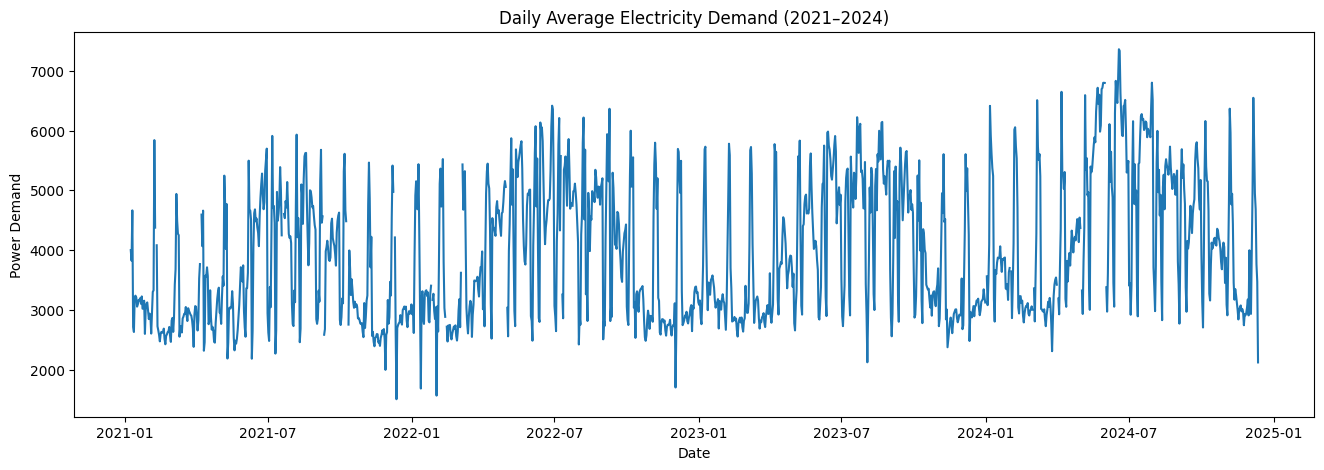

In [76]:
plt.figure(figsize=(16, 5))
daily_demand = data["Power_demand"].resample("D").mean()
plt.plot(daily_demand.index, daily_demand.values)
plt.title("Daily Average Electricity Demand (2021–2024)")
plt.xlabel("Date")
plt.ylabel("Power Demand")

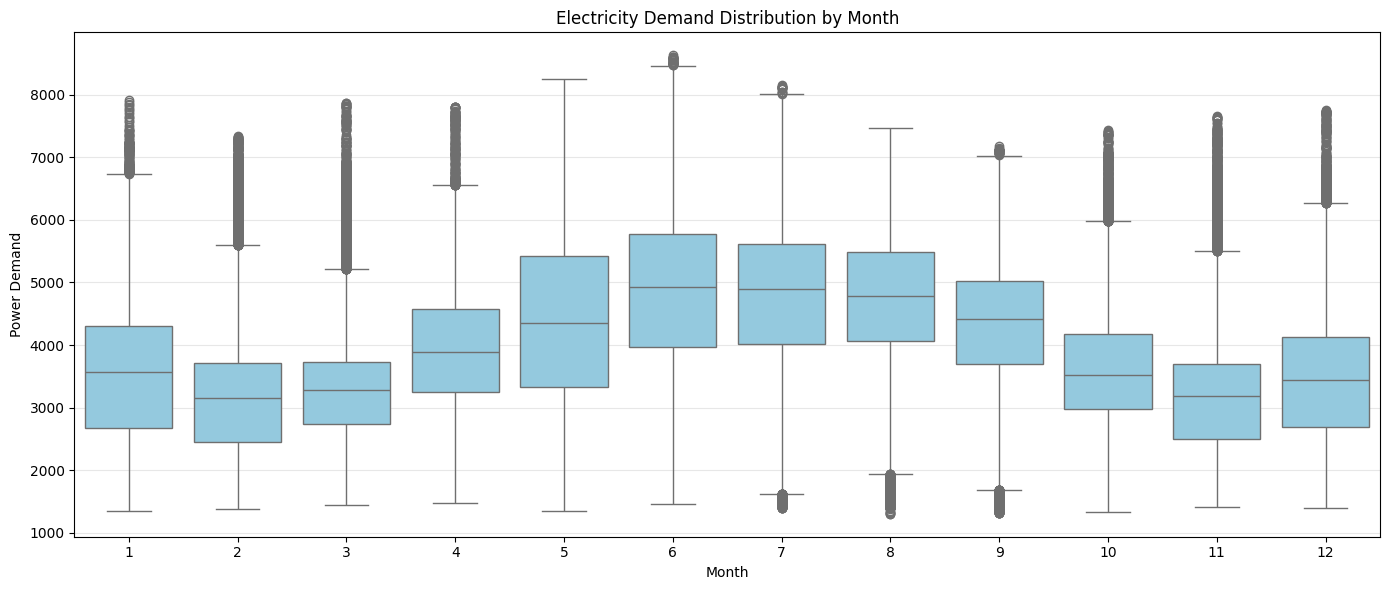

In [74]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=data, x="Month", y="Power_demand", color="skyblue")
plt.title("Electricity Demand Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Power Demand")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

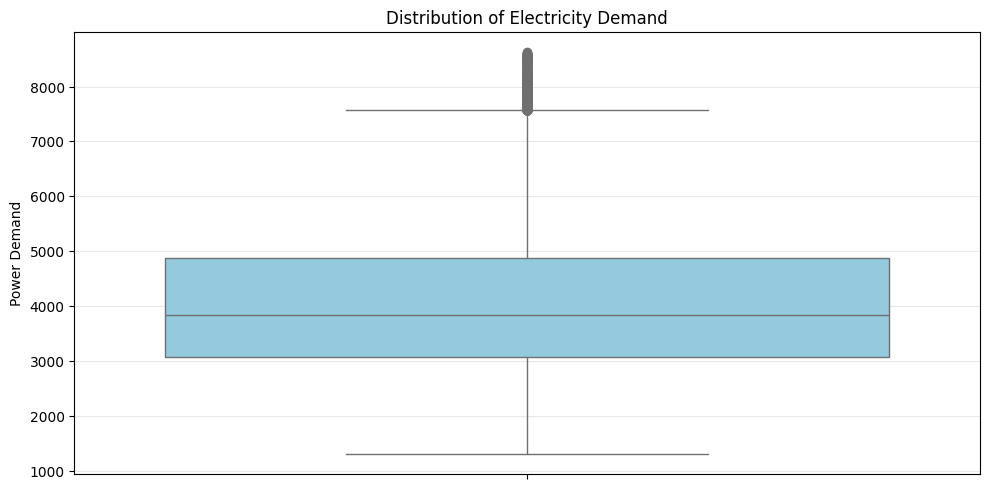

In [75]:
plt.figure(figsize=(10, 5))

sns.boxplot(y=data["Power_demand"], color="skyblue")

plt.title("Distribution of Electricity Demand")
plt.ylabel("Power Demand")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Demand')

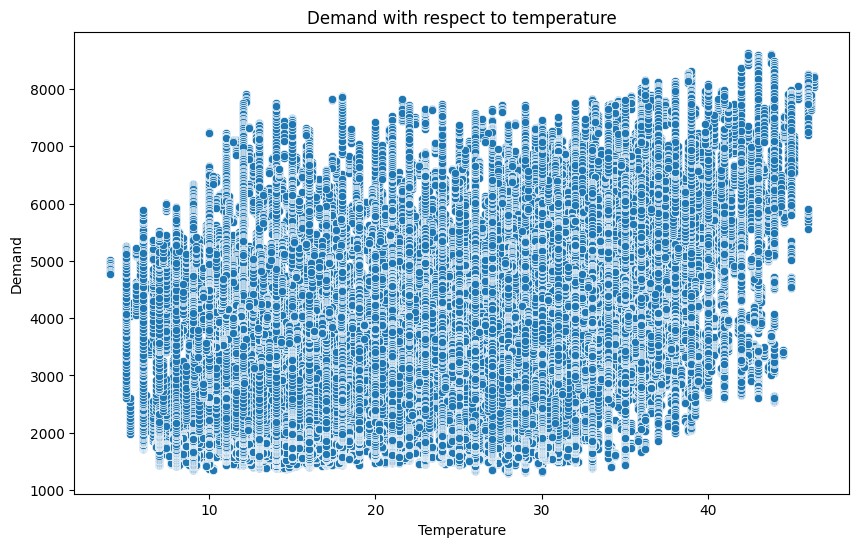

In [79]:
plt.figure(figsize = (10,6))
sns.scatterplot(data = data, x = 'Temperature', y = 'Power_demand')
plt.title('Demand with respect to temperature')
plt.ylabel('Demand')

<Axes: >

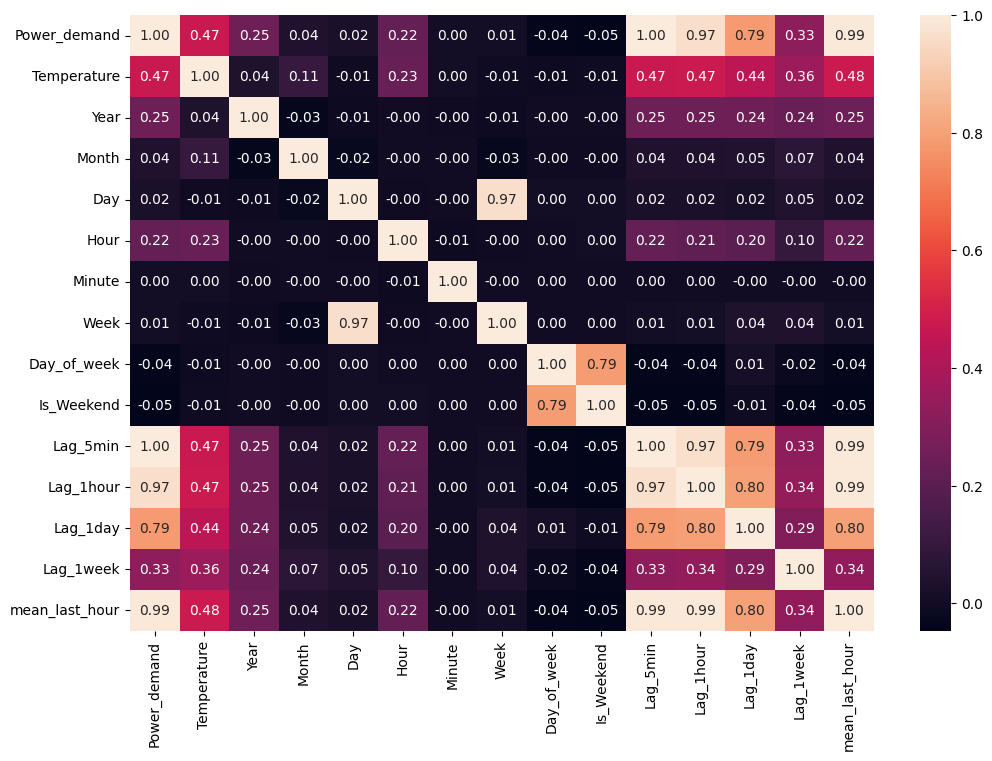

In [84]:
plt.figure(figsize = (12,8))
numeric_data = data.select_dtypes(include="number")
corr_matrix = numeric_data.corr()
sns.heatmap(corr_matrix, annot = True, fmt = '.2f')

In [86]:
Y = data['Power_demand']
Y

Datetime
2021-01-08 01:30:00    4422.85
2021-01-08 01:35:00    4376.57
2021-01-08 01:40:00    4388.63
2021-01-08 01:45:00    4364.30
2021-01-08 01:50:00    4350.35
                        ...   
2024-12-12 00:10:00    2146.84
2024-12-12 00:15:00    2116.66
2024-12-12 00:20:00    2082.77
2024-12-12 00:25:00    2059.17
2024-12-12 00:30:00    2049.66
Name: Power_demand, Length: 391424, dtype: float64

In [87]:
X = data.drop(columns = 'Power_demand')
X

,Temperature,Year,Month,Day,Hour,Minute,Week,Day_Name,Day_of_week,Is_Weekend,Lag_5min,Lag_1hour,Lag_1day,Lag_1week,mean_last_hour
Datetime,,,,,,,,,,,,,,,
2021-01-08 01:30:00,13.0,2021,1,8,1,30,2,Friday,5,0,4440.95,4692.64,6555.31,2014.00,4562.220000
2021-01-08 01:35:00,13.0,2021,1,8,1,35,2,Friday,5,0,4422.85,4653.47,6511.46,2005.63,4539.737500
2021-01-08 01:40:00,13.0,2021,1,8,1,40,2,Friday,5,0,4376.57,4645.90,6501.60,1977.60,4516.662500
2021-01-08 01:45:00,13.0,2021,1,8,1,45,2,Friday,5,0,4388.63,4624.05,6481.52,1976.44,4495.223333
2021-01-08 01:50:00,13.0,2021,1,8,1,50,2,Friday,5,0,4364.30,4610.83,6474.07,1954.37,4473.577500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-12 00:10:00,12.3,2024,12,12,0,10,2,Thursday,4,0,2154.75,3254.76,3716.93,4375.64,3014.500000
2024-12-12 00:15:00,12.3,2024,12,12,0,15,2,Thursday,4,0,2146.84,3246.70,3739.77,4307.08,2922.173333
2024-12-12 00:20:00,12.3,2024,12,12,0,20,2,Thursday,4,0,2116.66,3206.83,3739.81,4283.90,2828.003333


In [92]:
X_train = X.loc[ :'2023-12-31']
X_train

,Temperature,Year,Month,Day,Hour,Minute,Week,Day_Name,Day_of_week,Is_Weekend,Lag_5min,Lag_1hour,Lag_1day,Lag_1week,mean_last_hour
Datetime,,,,,,,,,,,,,,,
2021-01-08 01:30:00,13.0,2021,1,8,1,30,2,Friday,5,0,4440.95,4692.64,6555.31,2014.00,4562.220000
2021-01-08 01:35:00,13.0,2021,1,8,1,35,2,Friday,5,0,4422.85,4653.47,6511.46,2005.63,4539.737500
2021-01-08 01:40:00,13.0,2021,1,8,1,40,2,Friday,5,0,4376.57,4645.90,6501.60,1977.60,4516.662500
2021-01-08 01:45:00,13.0,2021,1,8,1,45,2,Friday,5,0,4388.63,4624.05,6481.52,1976.44,4495.223333
2021-01-08 01:50:00,13.0,2021,1,8,1,50,2,Friday,5,0,4364.30,4610.83,6474.07,1954.37,4473.577500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 22:25:00,12.0,2023,12,31,22,25,4,Sunday,7,1,2816.66,3068.88,3087.33,3455.64,2967.627500
2023-12-31 22:30:00,12.0,2023,12,31,22,30,4,Sunday,7,1,2800.17,3087.06,3065.44,3455.54,2945.235000
2023-12-31 22:35:00,12.0,2023,12,31,22,35,4,Sunday,7,1,2770.55,3047.32,3082.82,3455.80,2918.859167


In [94]:
Y_train = Y.loc[ :'2023-12-31']
Y_train

Datetime
2021-01-08 01:30:00    4422.85
2021-01-08 01:35:00    4376.57
2021-01-08 01:40:00    4388.63
2021-01-08 01:45:00    4364.30
2021-01-08 01:50:00    4350.35
                        ...   
2023-12-31 22:25:00    2800.17
2023-12-31 22:30:00    2770.55
2023-12-31 22:35:00    2770.55
2023-12-31 22:40:00    2770.55
2023-12-31 22:45:00    2770.55
Name: Power_demand, Length: 297159, dtype: float64

In [98]:
X_test = X.loc['2024-01-01': ]
X_test

,Temperature,Year,Month,Day,Hour,Minute,Week,Day_Name,Day_of_week,Is_Weekend,Lag_5min,Lag_1hour,Lag_1day,Lag_1week,mean_last_hour
Datetime,,,,,,,,,,,,,,,
2024-01-02 00:00:00,10.4,2024,1,2,0,0,1,Tuesday,2,0,2770.55,2998.99,3001.73,3397.24,2853.770000
2024-01-02 00:05:00,10.4,2024,1,2,0,5,1,Tuesday,2,0,2535.71,2965.15,2961.39,3404.04,2815.163333
2024-01-02 00:10:00,10.4,2024,1,2,0,10,1,Tuesday,2,0,2473.16,2946.68,2902.48,3339.72,2774.164167
2024-01-02 00:15:00,10.4,2024,1,2,0,15,1,Tuesday,2,0,2456.83,2897.02,2886.06,3322.04,2733.343333
2024-01-02 00:20:00,10.4,2024,1,2,0,20,1,Tuesday,2,0,2410.87,2883.73,2843.93,3332.15,2692.830833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-12 00:10:00,12.3,2024,12,12,0,10,2,Thursday,4,0,2154.75,3254.76,3716.93,4375.64,3014.500000
2024-12-12 00:15:00,12.3,2024,12,12,0,15,2,Thursday,4,0,2146.84,3246.70,3739.77,4307.08,2922.173333
2024-12-12 00:20:00,12.3,2024,12,12,0,20,2,Thursday,4,0,2116.66,3206.83,3739.81,4283.90,2828.003333


In [96]:
Y_test = Y.loc['2024-01-01': ]
Y_test

Datetime
2024-01-02 00:00:00    2535.71
2024-01-02 00:05:00    2473.16
2024-01-02 00:10:00    2456.83
2024-01-02 00:15:00    2410.87
2024-01-02 00:20:00    2378.55
                        ...   
2024-12-12 00:10:00    2146.84
2024-12-12 00:15:00    2116.66
2024-12-12 00:20:00    2082.77
2024-12-12 00:25:00    2059.17
2024-12-12 00:30:00    2049.66
Name: Power_demand, Length: 94265, dtype: float64

In [107]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

In [109]:
model_xgb = XGBRegressor(n_estimators=1000,early_stopping_rounds=50,learning_rate=0.01,random_state=42,objective="reg:squarederror")

In [111]:
X_train = X_train.drop(columns="Day_Name", errors="ignore")
X_test = X_test.drop(columns="Day_Name", errors="ignore")

In [115]:
model_xgb.fit(X_train, Y_train, eval_set = [(X_train,Y_train),(X_test,Y_test)], verbose = False)
print("XGBoost training completed.")

XGBoost training completed.


In [116]:
y_pred = model_xgb.predict(X_test)
mae = mean_absolute_error(Y_test, y_pred)
rmse = mean_squared_error(Y_test, y_pred) ** 0.5
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 42.32122113507508
RMSE: 117.79037132378105


In [117]:
mae = np.mean(np.abs(Y_test - y_pred))
rmse = np.sqrt(np.mean((Y_test - y_pred) ** 2))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 42.32122113507508
RMSE: 117.79037132378105


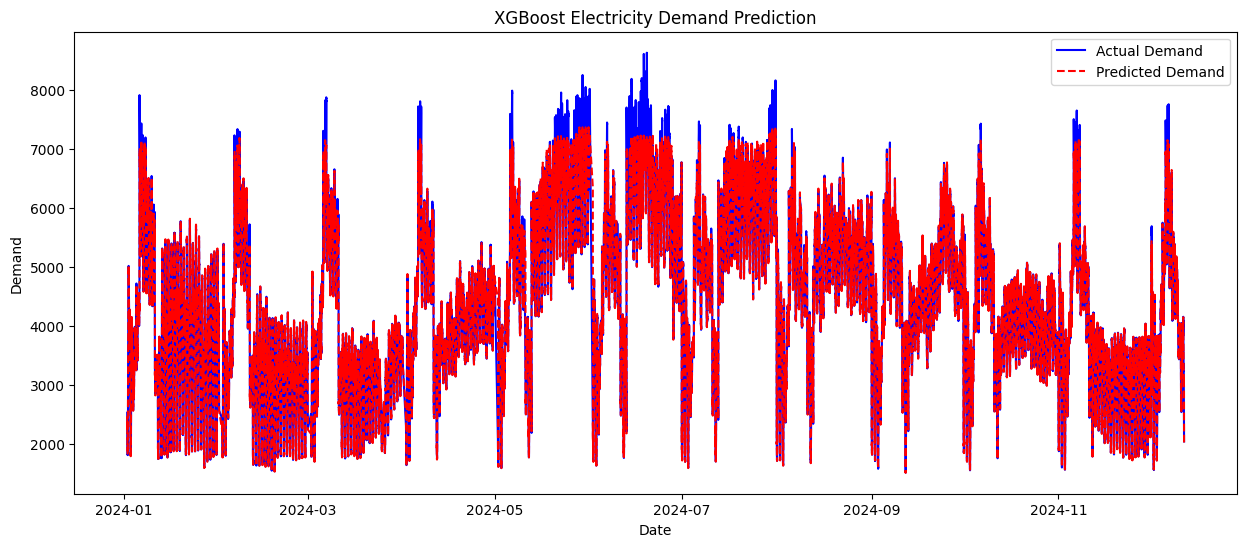

In [122]:
plt.figure(figsize=(15, 6))
plt.plot(Y_test.index, Y_test, label="Actual Demand", color="blue")
plt.plot(Y_test.index, y_pred, label="Predicted Demand", color="red", linestyle="--")
plt.title('XGBoost Electricity Demand Prediction')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.show()

In [123]:
import joblib
joblib.dump(model_xgb, "Electricity Demand Prediction Model.pkl")

['Electricity Demand Prediction Model.pkl']

In [124]:
loaded_model = joblib.load("Electricity Demand Prediction Model.pkl")